# Accessing Data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sahilnbajaj/lending-club-loan-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lending-club-loan-data' dataset.
Path to dataset files: /kaggle/input/lending-club-loan-data


In [ ]:
import os

# List the contents of the downloaded directory
print(f"Contents of the directory '{path}':")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Contents of the directory '/kaggle/input/lending-club-loan-data':
/kaggle/input/lending-club-loan-data/lending_club_info.csv
/kaggle/input/lending-club-loan-data/lending_club_loan_two.csv


In [ ]:
from google.colab import files

# Example: Assuming a file named 'lending_club_loan_data.csv' is in the downloaded directory
# You might need to adjust the actual filename
file_to_download = os.path.join(path, 'lending_club_loan_two.csv') # Replaced with an actual file name found in the directory

if os.path.exists(file_to_download):
    files.download(file_to_download)
    print(f"Downloading '{file_to_download}' to your local machine.")
else:
    print(f"File '{file_to_download}' not found. Please check the correct filename from the list above.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Data Pre-Processing

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(os.path.join(path, 'lending_club_loan_two.csv'))
pd.set_option('display.max_columns', None)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.00,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.00,Not Verified,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.00,0.00,36369.00,41.80,25.00,w,INDIVIDUAL,0.00,0.00,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.00,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.00,Not Verified,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.00,0.00,20131.00,53.30,27.00,f,INDIVIDUAL,3.00,0.00,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.00,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.00,Source Verified,Jan-2015,Fully Paid,credit_card,Credit card refinancing,12.79,Aug-2007,13.00,0.00,11987.00,92.20,26.00,f,INDIVIDUAL,0.00,0.00,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.00,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.00,Not Verified,Nov-2014,Fully Paid,credit_card,Credit card refinancing,2.60,Sep-2006,6.00,0.00,5472.00,21.50,13.00,f,INDIVIDUAL,0.00,0.00,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.00,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.00,Verified,Apr-2013,Charged Off,credit_card,Credit Card Refinance,33.95,Mar-1999,13.00,0.00,24584.00,69.80,43.00,f,INDIVIDUAL,1.00,0.00,"679 Luna Roads\nGreggshire, VA 11650"


# Values Review

In [ ]:
print(df['term'].unique())
df['term'].value_counts()

[' 36 months' ' 60 months']


,count
term,
36 months,302005
60 months,94025


In [ ]:
print(df['emp_length'].unique())
df['emp_length'].value_counts()

['10+ years' '4 years' '< 1 year' '6 years' '9 years' '2 years' '3 years'
 '8 years' '7 years' '5 years' '1 year' nan]


,count
emp_length,
10+ years,126041
2 years,35827
< 1 year,31725
3 years,31665
5 years,26495
1 year,25882
4 years,23952
6 years,20841
7 years,20819


In [ ]:
print(df['grade'].unique())

['B' 'A' 'C' 'E' 'D' 'F' 'G']


In [ ]:
print(df['sub_grade'].unique())
df['sub_grade'].value_counts()

['B4' 'B5' 'B3' 'A2' 'C5' 'C3' 'A1' 'B2' 'C1' 'A5' 'E4' 'A4' 'A3' 'D1'
 'C2' 'B1' 'D3' 'D5' 'D2' 'E1' 'E2' 'E5' 'F4' 'E3' 'D4' 'G1' 'F5' 'G2'
 'C4' 'F1' 'F3' 'G5' 'G4' 'F2' 'G3']


,count
sub_grade,
B3,26655
B4,25601
C1,23662
C2,22580
B2,22495
B5,22085
C3,21221
C4,20280
B1,19182


In [ ]:
print(df['verification_status'].unique())

['Not Verified' 'Source Verified' 'Verified']


In [ ]:
print(df['loan_status'].unique())

['Fully Paid' 'Charged Off']


In [ ]:
print(df['purpose'].unique())
df['purpose'].value_counts()

['vacation' 'debt_consolidation' 'credit_card' 'home_improvement'
 'small_business' 'major_purchase' 'other' 'medical' 'wedding' 'car'
 'moving' 'house' 'educational' 'renewable_energy']


,count
purpose,
debt_consolidation,234507
credit_card,83019
home_improvement,24030
other,21185
major_purchase,8790
small_business,5701
car,4697
medical,4196
moving,2854


In [ ]:
print(df['initial_list_status'].unique())

['w' 'f']


In [ ]:
print(df['application_type'].unique())

['INDIVIDUAL' 'JOINT' 'DIRECT_PAY']


In [ ]:
pd.concat([df['home_ownership'].value_counts(),
           df['home_ownership'].value_counts(normalize=True) * 100],
          axis=1, keys=['count', 'percentage'])

,count,percentage
home_ownership,,
MORTGAGE,198348,50.08
RENT,159790,40.35
OWN,37746,9.53
OTHER,112,0.03
NONE,31,0.01
ANY,3,0.00


In [ ]:
print(df['pub_rec_bankruptcies'].unique())
df['pub_rec_bankruptcies'].value_counts()

[ 0.  1.  2.  3. nan  4.  5.  6.  7.  8.]


,count
pub_rec_bankruptcies,
0.00,350380
1.00,42790
2.00,1847
3.00,351
4.00,82
5.00,32
6.00,7
7.00,4
8.00,2


# 0. Dropping Values

In [ ]:
#Drop columns we won't measure
columns_to_drop = ['emp_title', 'title', 'issue_d', 'initial_list_status', 'application_type', 'verification_status', 'address']#, 'purpose']
#Kept the "purpose" column to eliminate "house" loan values

# Filter out columns that do not exist in df before dropping
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

df = df.drop(columns=existing_columns_to_drop)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_length            377729 non-null  object 
 7   home_ownership        396030 non-null  object 
 8   annual_inc            396030 non-null  float64
 9   loan_status           396030 non-null  object 
 10  purpose               396030 non-null  object 
 11  dti                   396030 non-null  float64
 12  earliest_cr_line      396030 non-null  object 
 13  open_acc              396030 non-null  float64
 14  pub_rec               396030 non-null  float64
 15  

# 1. Identify Missing Values

In [ ]:
#identify columns with missing values
for c in df.columns:
    miss = df[c].isnull().sum()
    if miss!=0:
        print("{} has {} missing value(s)".format(c,miss))

emp_length has 18301 missing value(s)
revol_util has 276 missing value(s)
mort_acc has 37795 missing value(s)
pub_rec_bankruptcies has 535 missing value(s)


In [ ]:
#drop all rows where data is missing from any of the columns
#instead of dropping these rows, we will impute values
#df = df.dropna()

In [ ]:
# Filter out columns that do not exist in df
#existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
#df = df.drop(columns=existing_columns_to_drop)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_length            377729 non-null  object 
 7   home_ownership        396030 non-null  object 
 8   annual_inc            396030 non-null  float64
 9   loan_status           396030 non-null  object 
 10  purpose               396030 non-null  object 
 11  dti                   396030 non-null  float64
 12  earliest_cr_line      396030 non-null  object 
 13  open_acc              396030 non-null  float64
 14  pub_rec               396030 non-null  float64
 15  

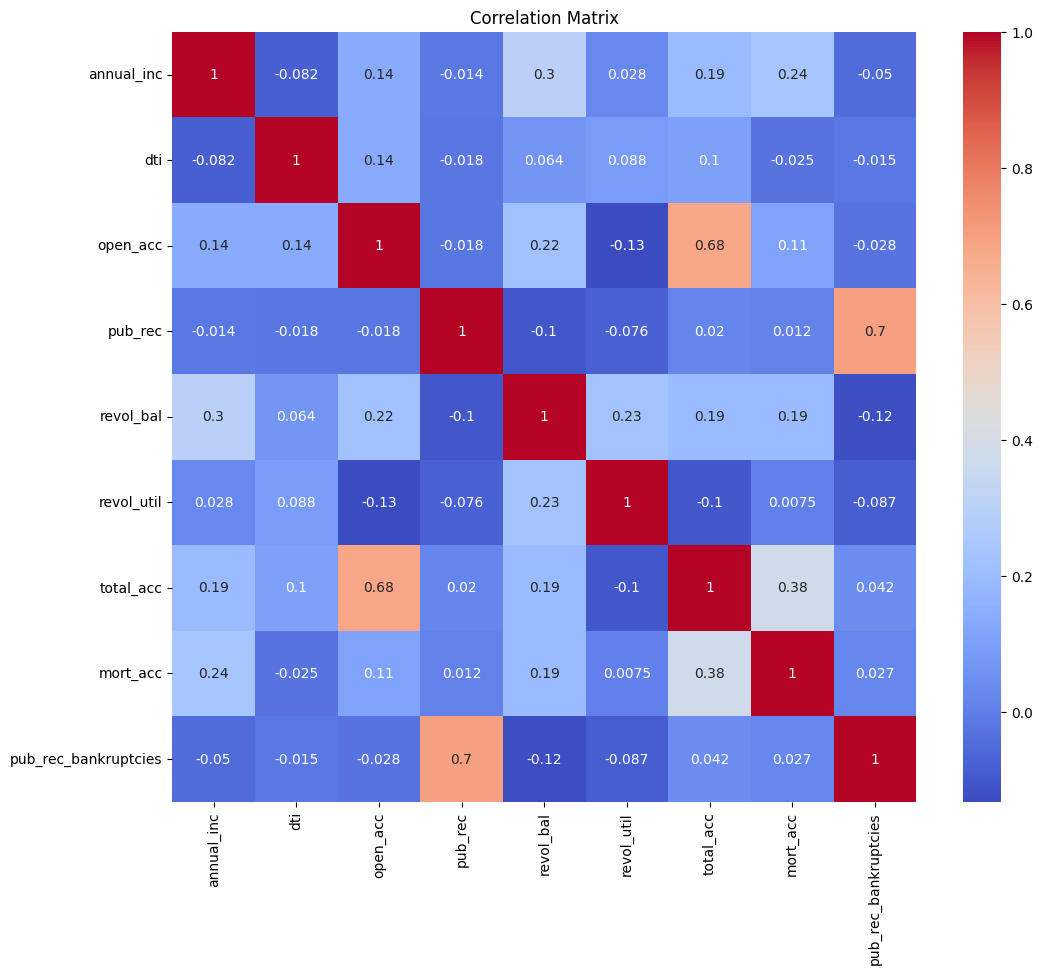

In [ ]:
# Exploratory Data Analysis
temp_df = df.iloc[:, 6:].select_dtypes(include=['number'])
#temp_df = df.iloc[:, 5:18].copy()

# Calculate and plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

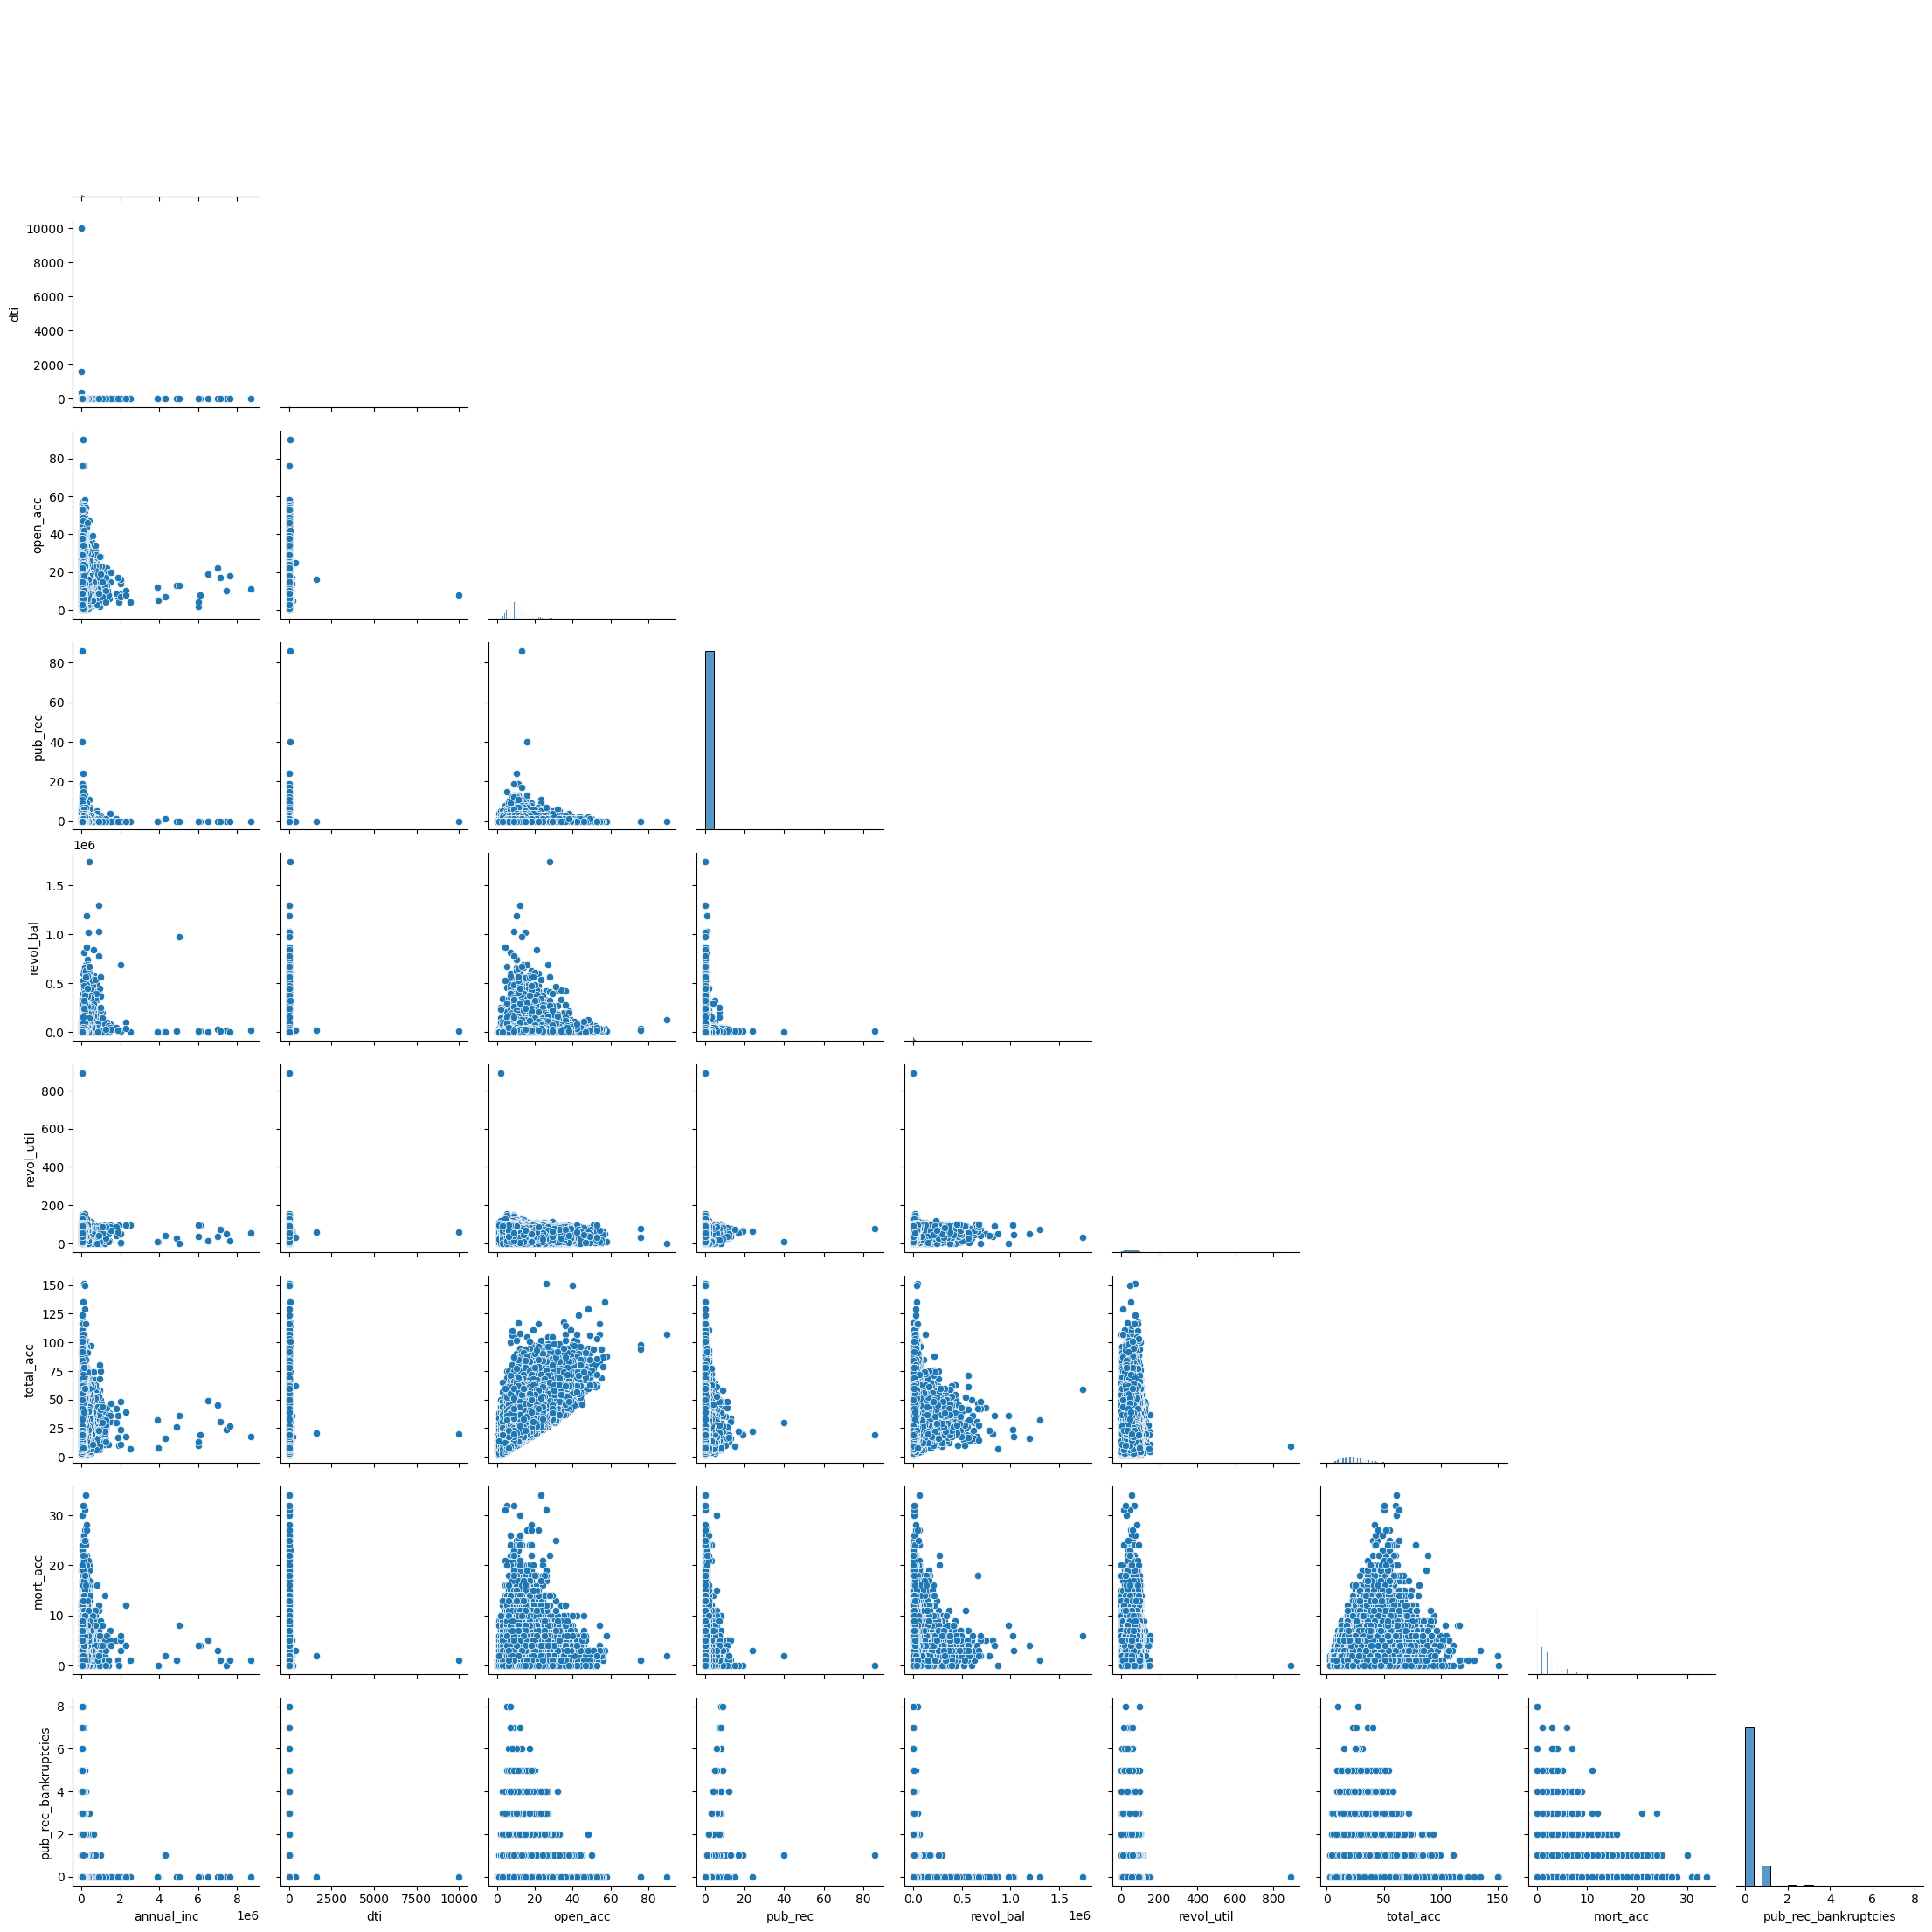

In [ ]:
#only print half of the pairplot (top diagonal is duplicate charts)
#to print a square chart, remove ", corner=True" from sns.pairplot"
pairplot_df = df.iloc[:, 5:].copy().select_dtypes(include=['number'])
sns.pairplot(pairplot_df, corner=True)
plt.show()

# 2. Identify and Remove Outliers

In [ ]:
#IQR method for removing outliers
#Identify columns from which outliers need to be excluded
cols_to_check = ['annual_inc',  'dti', 'open_acc', 'revol_bal', 'revol_util']

#Initialize a mask of "False" (meaning no outliers yet)
master_outlier_mask = pd.Series(False, index=df.index)

for col in cols_to_check:
    # Calculate bounds
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    #setting caps at 1.5 eliminates 54500 and leaves 341384 rows (13.77%)
    #setting at 2 eliminates 31178 and leaves 364706 rows (7.88%)
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    # Identify outliers in THIS column
    current_outliers = (df[col] < lower) | (df[col] > upper)

    # Add these outliers to our master list using "OR" (|)
    master_outlier_mask = master_outlier_mask | current_outliers

#Calculate results
total_eliminated = master_outlier_mask.sum()
remaining_rows = len(df) - total_eliminated
percent_lost = (total_eliminated / len(df)) * 100

print(f"Total rows to be eliminated: {total_eliminated}")
print(f"Percentage of data lost: {percent_lost:.2f}%")
print(f"Rows remaining: {remaining_rows}")

Total rows to be eliminated: 13025
Percentage of data lost: 3.29%
Rows remaining: 383005


In [ ]:
#to remove upper and lower IQR
df[col] = df[col].clip(lower, upper)

# 3. Imputation

In [ ]:
# Imputer for numerical columns
num_imputer = SimpleImputer(strategy='mean')

# Imputer for categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')

df['term'] = (df['term'].astype(str)
    .str.replace(' months', '', regex=False)
    .str.strip()
    .astype(float))

df['emp_length'] = (df['emp_length'].astype(str)
    .str.replace('+', '', regex=False) # Remove '+'
    .str.replace('<', '', regex=False) # Remove '<'
    .str.replace('years', '', regex=False) # Replace plural 'years' first
    .str.replace('year', '', regex=False)  # Then replace singular 'year'
    .str.strip()
    .astype(float))

In [ ]:
df['emp_length'] = num_imputer.fit_transform(df[['emp_length']])
#df = df.dropna(subset=['emp_length']) Temporarily attempted dropping NA emp_length instead of imputing
df['revol_util'] = num_imputer.fit_transform(df[['revol_util']])
df['mort_acc'] = num_imputer.fit_transform(df[['mort_acc']])
df['pub_rec_bankruptcies'] = num_imputer.fit_transform(df[['pub_rec_bankruptcies']])
df['revol_bal'] = num_imputer.fit_transform(df[['revol_bal']])

In [ ]:
for c in df.columns:
    miss = df[c].isnull().sum()
    if miss!=0:
        print("{} has {} missing value(s)".format(c,miss))

# 4. Transforming

In [ ]:
# Converting Earliest_Cr_Line_Year from Month & Year to just Year

df['earliest_cr_line_year'] = df['earliest_cr_line'].apply(lambda date_str: int(date_str.split('-')[1]))
df = df.drop('earliest_cr_line', axis=1)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   loan_amnt              396030 non-null  float64
 1   term                   396030 non-null  float64
 2   int_rate               396030 non-null  float64
 3   installment            396030 non-null  float64
 4   grade                  396030 non-null  object 
 5   sub_grade              396030 non-null  object 
 6   emp_length             396030 non-null  float64
 7   home_ownership         396030 non-null  object 
 8   annual_inc             396030 non-null  float64
 9   loan_status            396030 non-null  object 
 10  purpose                396030 non-null  object 
 11  dti                    396030 non-null  float64
 12  open_acc               396030 non-null  float64
 13  pub_rec                396030 non-null  float64
 14  revol_bal              396030 non-nu

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,earliest_cr_line_year
0,10000.00,36.00,11.44,329.48,B,B4,10.00,RENT,117000.00,Fully Paid,vacation,26.24,16.00,0.00,36369.00,41.80,25.00,0.00,0.00,1990
1,8000.00,36.00,11.99,265.68,B,B5,4.00,MORTGAGE,65000.00,Fully Paid,debt_consolidation,22.05,17.00,0.00,20131.00,53.30,27.00,3.00,0.00,2004
2,15600.00,36.00,10.49,506.97,B,B3,1.00,RENT,43057.00,Fully Paid,credit_card,12.79,13.00,0.00,11987.00,92.20,26.00,0.00,0.00,2007
3,7200.00,36.00,6.49,220.65,A,A2,6.00,RENT,54000.00,Fully Paid,credit_card,2.60,6.00,0.00,5472.00,21.50,13.00,0.00,0.00,2006
4,24375.00,60.00,17.27,609.33,C,C5,9.00,MORTGAGE,55000.00,Charged Off,credit_card,33.95,13.00,0.00,24584.00,69.80,43.00,1.00,0.00,1999


In [ ]:
import datetime

current_year = datetime.datetime.now().year
df['credit_age'] = current_year - df['earliest_cr_line_year']
df = df.drop('earliest_cr_line_year', axis=1)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  float64
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_length            396030 non-null  float64
 7   home_ownership        396030 non-null  object 
 8   annual_inc            396030 non-null  float64
 9   loan_status           396030 non-null  object 
 10  purpose               396030 non-null  object 
 11  dti                   396030 non-null  float64
 12  open_acc              396030 non-null  float64
 13  pub_rec               396030 non-null  float64
 14  revol_bal             396030 non-null  float64
 15  

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,credit_age
0,10000.00,36.00,11.44,329.48,B,B4,10.00,RENT,117000.00,Fully Paid,vacation,26.24,16.00,0.00,36369.00,41.80,25.00,0.00,0.00,36
1,8000.00,36.00,11.99,265.68,B,B5,4.00,MORTGAGE,65000.00,Fully Paid,debt_consolidation,22.05,17.00,0.00,20131.00,53.30,27.00,3.00,0.00,22
2,15600.00,36.00,10.49,506.97,B,B3,1.00,RENT,43057.00,Fully Paid,credit_card,12.79,13.00,0.00,11987.00,92.20,26.00,0.00,0.00,19
3,7200.00,36.00,6.49,220.65,A,A2,6.00,RENT,54000.00,Fully Paid,credit_card,2.60,6.00,0.00,5472.00,21.50,13.00,0.00,0.00,20
4,24375.00,60.00,17.27,609.33,C,C5,9.00,MORTGAGE,55000.00,Charged Off,credit_card,33.95,13.00,0.00,24584.00,69.80,43.00,1.00,0.00,27


In [ ]:
#Can remove outliers now that credit age is transformed
cols_to_check = ['credit_age']

#Initialize a mask of "False" (meaning no outliers yet)
master_outlier_mask = pd.Series(False, index=df.index)

for col in cols_to_check:
    # Calculate bounds
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    #setting caps at 3
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    # Identify outliers in THIS column
    current_outliers = (df[col] < lower) | (df[col] > upper)

    # Add these outliers to our master list using "OR" (|)
    master_outlier_mask = master_outlier_mask | current_outliers

#Calculate results
total_eliminated = master_outlier_mask.sum()
remaining_rows = len(df) - total_eliminated
percent_lost = (total_eliminated / len(df)) * 100

print(f"Total rows to be eliminated: {total_eliminated}")
print(f"Percentage of data lost: {percent_lost:.2f}%")
print(f"Rows remaining: {remaining_rows}")

Total rows to be eliminated: 510
Percentage of data lost: 0.13%
Rows remaining: 395520


In [ ]:
#to remove upper and lower IQR
df[col] = df[col].clip(lower, upper)

In [ ]:
# Transforming Sub_Grade

# Get all unique sub_grades and sort them
# This ensures a consistent numerical order for mapping
sub_grade_unique = sorted(df['sub_grade'].astype(str).str.strip().unique())

# Create a dictionary mapping each sub_grade to an integer
sub_grade_mapping = {sub_grade: i for i, sub_grade in enumerate(sub_grade_unique)}

# Apply the mapping to the 'sub_grade' column
df['sub_grade'] = df['sub_grade'].astype(str).str.strip().map(sub_grade_mapping)

df['sub_grade'].value_counts().sort_index()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  float64
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  int64  
 6   emp_length            396030 non-null  float64
 7   home_ownership        396030 non-null  object 
 8   annual_inc            396030 non-null  float64
 9   loan_status           396030 non-null  object 
 10  purpose               396030 non-null  object 
 11  dti                   396030 non-null  float64
 12  open_acc              396030 non-null  float64
 13  pub_rec               396030 non-null  float64
 14  revol_bal             396030 non-null  float64
 15  

In [ ]:
#Confirming sub_grade transformation works.

print(df['sub_grade'].unique())


[ 8  9  7  1 14 12  0  6 10  4 23  3  2 15 11  5 17 19 16 20 21 24 28 22
 18 30 29 31 13 25 27 34 33 26 32]


In [ ]:
#Transforming loan_status

df['loan_status'] = df['loan_status'].astype(str).str.strip().map({
    'Fully Paid': 1,
    'Charged Off': 0,
})

df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,credit_age
0,10000.00,36.00,11.44,329.48,B,8,10.00,RENT,117000.00,1,vacation,26.24,16.00,0.00,36369.00,41.80,25.00,0.00,0.00,36
1,8000.00,36.00,11.99,265.68,B,9,4.00,MORTGAGE,65000.00,1,debt_consolidation,22.05,17.00,0.00,20131.00,53.30,27.00,3.00,0.00,22
2,15600.00,36.00,10.49,506.97,B,7,1.00,RENT,43057.00,1,credit_card,12.79,13.00,0.00,11987.00,92.20,26.00,0.00,0.00,19
3,7200.00,36.00,6.49,220.65,A,1,6.00,RENT,54000.00,1,credit_card,2.60,6.00,0.00,5472.00,21.50,13.00,0.00,0.00,20
4,24375.00,60.00,17.27,609.33,C,14,9.00,MORTGAGE,55000.00,0,credit_card,33.95,13.00,0.00,24584.00,69.80,43.00,1.00,0.00,27


In [ ]:
#Confirming loan_status works

print(df['loan_status'].unique())

[1 0]


In [ ]:
# Drop rows where 'column_value' is exactly 'target_value'
#df = df[df['home_ownership'] != 'OWN']
#~df['col'].isin(['val1', 'val2'])
keep_list = ['RENT', 'MORTGAGE', 'OWN']

# Keep rows where the column matches any item in the list
df = df[df['home_ownership'].isin(keep_list)]

print(df['home_ownership'].unique())
#df['home_ownership'].value_counts()


['RENT' 'MORTGAGE' 'OWN']


In [ ]:
df['home_ownership'] = df['home_ownership'].astype(str).str.strip().map({
    'RENT': 0,
    'MORTGAGE': 1,
    'OWN': 1
})

In [ ]:
# Drop rows where purpose is house, home improvement
df = df[~df['purpose'].isin(['house', 'home_improvement'])]

#confirm drop
print(df['purpose'].unique())
df['purpose'].value_counts()

['vacation' 'debt_consolidation' 'credit_card' 'small_business'
 'major_purchase' 'other' 'medical' 'wedding' 'car' 'moving' 'educational'
 'renewable_energy']


,count
purpose,
debt_consolidation,234455
credit_card,82974
other,21171
major_purchase,8785
small_business,5694
car,4695
medical,4193
moving,2854
vacation,2452


In [ ]:
#Move object data type columns to beginning
cols_to_move = ['grade', 'term', 'loan_status', 'purpose','sub_grade', 'home_ownership']

new_order = cols_to_move + [c for c in df.columns if c not in cols_to_move]

df = df[new_order]

df.head()

,grade,term,loan_status,purpose,sub_grade,home_ownership,loan_amnt,int_rate,installment,emp_length,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,credit_age
0,B,36.00,1,vacation,8,0,10000.00,11.44,329.48,10.00,117000.00,26.24,16.00,0.00,36369.00,41.80,25.00,0.00,0.00,36
1,B,36.00,1,debt_consolidation,9,1,8000.00,11.99,265.68,4.00,65000.00,22.05,17.00,0.00,20131.00,53.30,27.00,3.00,0.00,22
2,B,36.00,1,credit_card,7,0,15600.00,10.49,506.97,1.00,43057.00,12.79,13.00,0.00,11987.00,92.20,26.00,0.00,0.00,19
3,A,36.00,1,credit_card,1,0,7200.00,6.49,220.65,6.00,54000.00,2.60,6.00,0.00,5472.00,21.50,13.00,0.00,0.00,20
4,C,60.00,0,credit_card,14,1,24375.00,17.27,609.33,9.00,55000.00,33.95,13.00,0.00,24584.00,69.80,43.00,1.00,0.00,27


In [ ]:
#change large numbers from scientific notation to float.2 decimals
pd.options.display.float_format = '{:.2f}'.format
print(df.describe())

           term  loan_status  sub_grade  home_ownership  loan_amnt  int_rate  \
count 369666.00    369666.00  369666.00       369666.00  369666.00 369666.00   
mean      41.66         0.80      11.10            0.58   14107.01     13.66   
std       10.19         0.40       6.57            0.49    8301.94      4.45   
min       36.00         0.00       0.00            0.00     500.00      5.32   
25%       36.00         1.00       6.00            0.00    8000.00     10.49   
50%       36.00         1.00      10.00            1.00   12000.00     13.33   
75%       36.00         1.00      15.00            1.00   20000.00     16.55   
max       60.00         1.00      34.00            1.00   40000.00     30.99   

       installment  emp_length  annual_inc       dti  open_acc   pub_rec  \
count    369666.00   369666.00   369666.00 369666.00 369666.00 369666.00   
mean        432.10        6.00    73053.08     17.58     11.34      0.17   
std         249.15        3.44    57196.15     18.5

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 369666 entries, 0 to 396029
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   grade                 369666 non-null  object 
 1   term                  369666 non-null  float64
 2   loan_status           369666 non-null  int64  
 3   purpose               369666 non-null  object 
 4   sub_grade             369666 non-null  int64  
 5   home_ownership        369666 non-null  int64  
 6   loan_amnt             369666 non-null  float64
 7   int_rate              369666 non-null  float64
 8   installment           369666 non-null  float64
 9   emp_length            369666 non-null  float64
 10  annual_inc            369666 non-null  float64
 11  dti                   369666 non-null  float64
 12  open_acc              369666 non-null  float64
 13  pub_rec               369666 non-null  float64
 14  revol_bal             369666 non-null  float64
 15  revol

# Summary of data processing completed:
<b>Dropped columns:</b> 'emp_title', 'title', 'issue_d', 'initial_list_status', 'application_type', 'verification_status', 'address'</br>
<b>Removed outliers[(IQR 1 and 3) * 3]:</b> 'annual_inc',  'dti', 'open_acc', 'revol_bal', 'revol_util'</br>
<b>Removed rows:</b>
-'home_ownership'-removed "any", "none", "other", keeping only "rent", "mortgage", "own"</br>
-'purpose' - removed "house" and "home improvement" as purpose for loan</br>
<b>Imputed mean or most frequent values:</b> 'emp_length','revol_util','mort_acc', 'pub_rec_bankruptcies'</br>
<b>Transformed:</b></br>
-'Earliest credit year' --> 'credit_age'</br>
-'sub-grade' (letter#) --> individual numbers</br>
-Loan status: 'Charged Off' --> 0, 'Fully Paid'--> 1,</br>
-'home_ownership': Renter --> 0, "own" and "mortgage" --> 1
    

In [ ]:
import os
from google.colab import drive

#Mount Google Drive to store df/ file
drive.mount('/content/drive')

#Define your folder path and filename
folder_path = '/content/drive/My Drive/MSBA 6620 Group Project'
file_name = 'processed_loan_data.pkl'
full_path = os.path.join(folder_path, file_name)

# Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Created new folder: {folder_path}")

# Save the DataFrame
# Using pickle (.pkl) is to save data types (integers vs objects)
df.to_pickle(full_path)

print(f"File saved successfully to: {full_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File saved successfully to: /content/drive/My Drive/MSBA 6620 Group Project/processed_loan_data.pkl


## Summary of Transformed Columns and Their Meanings

Here's a breakdown of the columns in your DataFrame that were transformed into new numerical values, and what those new values signify:

1.  **`term`**:
    *   **Original Value**: Categorical strings like ' 36 months' or ' 60 months'.
    *   **New Value**: Converted to `float64` representing the loan term in months.
        *   `36.0` for ' 36 months'
        *   `60.0` for ' 60 months'

2.  **`emp_length`**:
    *   **Original Value**: Categorical strings representing employment length (e.g., '10+ years', '4 years', '< 1 year').
    *   **New Value**: Converted to `float64` representing the number of years of employment.
        *   '10+ years' mapped to `10.0`
        *   '4 years' mapped to `4.0`
        *   '< 1 year' mapped to `1.0` (or `0.0` depending on the interpretation, but here it was mapped to `1.0` effectively after stripping '<')

3.  **`credit_age`**:
    *   **Original Value**: Derived from `earliest_cr_line`, which was in 'Mon-YYYY' string format (e.g., 'Jan-1990').
    *   **New Value**: Integer representing the number of years since the earliest credit line was opened (Current Year - `earliest_cr_line_year`).

4.  **`sub_grade`**:
    *   **Original Value**: Hierarchical categorical strings (e.g., 'A1', 'A2', 'B1', 'C5').
    *   **New Value**: Converted to `int64` representing a numerical rank of the sub-grade, where lower numbers indicate better grades.
        *   'A1' maps to `0`, 'A2' maps to `1`, ..., 'G5' maps to `34`.

5.  **`loan_status`**:
    *   **Original Value**: Categorical strings ('Fully Paid', 'Charged Off').
    *   **New Value**: Converted to `int64` to serve as the target variable for a classification model.
        *   'Fully Paid' maps to `1` (representing a successful loan).
        *   'Charged Off' maps to `0` (representing a defaulted loan).

*Glossary for Terms*
1. Loan amount: the total principal amount of money borrowed by the borrower
2. Term: the length of time over which the loan is scheduled to be repaid, typically expressed in months (36 or 60 months)
3. Interest rate: the annual percentage rate charged on the loan balance
4. Installment: the fixed periodic payment amount the borrower is required to make, including principal and interest
5. Sub grade: a finer classification within a broader credit grade that reflects the borrower’s credit risk (e.g., A1–G5), with higher subgrades indicating higher risk (in our dataset, we transformed these to be numerical)
6. Employment length: the number of years the borrower has been employed
7. Annual income: the borrower’s self-reported annual income during registration
7. DTI (Debt-to-Income ratio): the percentage of the borrower’s monthly income that goes toward debt payments
8. Open accounts: the number of open credit lines in the borrower's credit file
9. Public records: the number of derogatory public record events associated with the borrower, such as liens or judgments
10. Revolving balance: the total outstanding balance on revolving credit accounts, such as credit cards
11. Revolving utilization: the percentage of available revolving credit that is currently being used
12. Total accounts: the total number of credit accounts the borrower has had, including open and closed accounts
**13. Mort_acc:** the number of mortgage accounts held by the borrower
**14. Pub_rec_bankruptcies:** the number of bankruptcy filings recorded in the borrower’s public credit records
**15. Credit age:** transformed from earliest_cr_line, this is the length of time the borrower has had credit, measured as the age of their oldest credit account